Import Libraries & Load Data

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/dsrscientist/dataset1/master/census_income.csv')
df.head(30)

,Age,Workclass,Fnlwgt,Education,Education_num,Marital_status,Occupation,Relationship,Race,Sex,Capital_gain,Capital_loss,Hours_per_week,Native_country,Income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
5,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
6,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
7,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
8,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K
9,37,Private,280464,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,80,United-States,>50K


Exploratory Data Analysis (EDA)

In [180]:
df.describe()

,Age,Fnlwgt,Education_num,Capital_gain,Capital_loss,Hours_per_week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [181]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing Values:
Age               0
Workclass         0
Fnlwgt            0
Education         0
Education_num     0
Marital_status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_gain      0
Capital_loss      0
Hours_per_week    0
Native_country    0
Income            0
dtype: int64

Duplicates: 24


In [182]:
# check ' ?' values
df.isin([' ?']).sum()

Age                  0
Workclass         1836
Fnlwgt               0
Education            0
Education_num        0
Marital_status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_gain         0
Capital_loss         0
Hours_per_week       0
Native_country     583
Income               0
dtype: int64

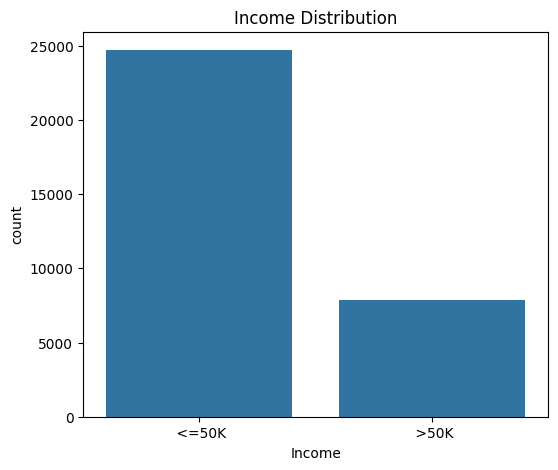

In [183]:
#Income Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Income',data=df)
plt.title("Income Distribution")
plt.show()

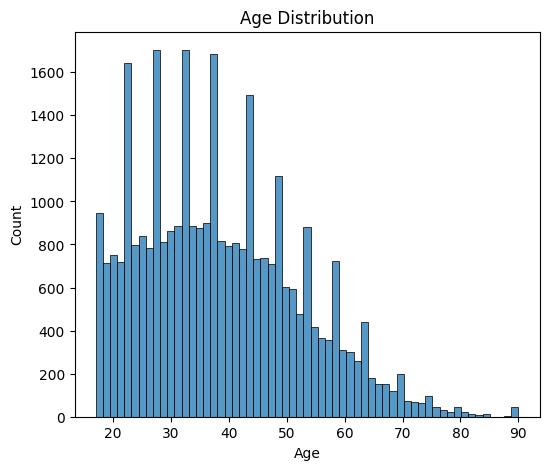

In [184]:
#Age Distribution
plt.figure(figsize=(6,5))
sns.histplot(x='Age',data=df)
plt.title("Age Distribution")
plt.show()

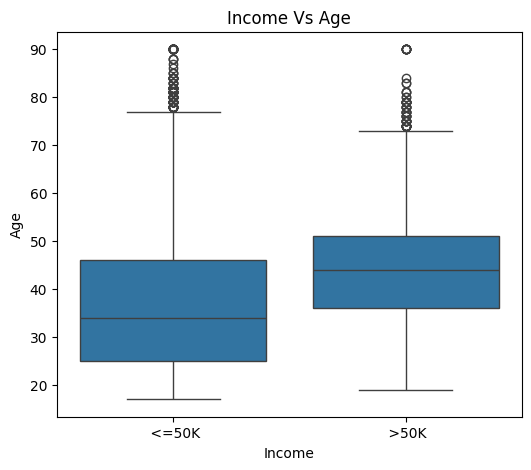

In [185]:
#compare between Age & Income
plt.figure(figsize=(6,5))
sns.boxplot(x='Income',y='Age',data=df)
plt.title("Income Vs Age")
plt.show()

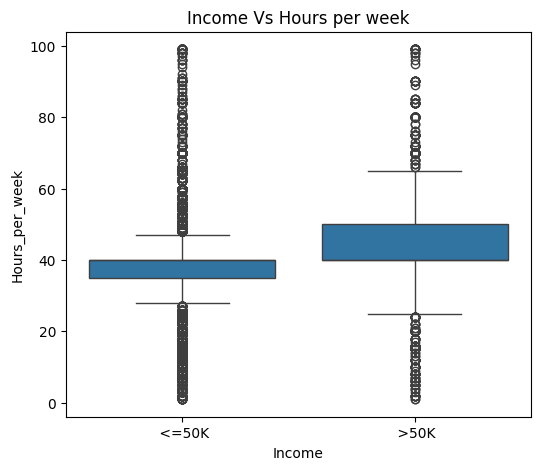

In [186]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Income',y='Hours_per_week',data=df)
plt.title("Income Vs Hours per week")
plt.show()

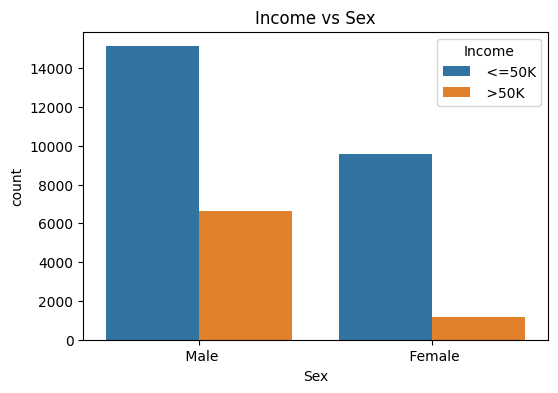

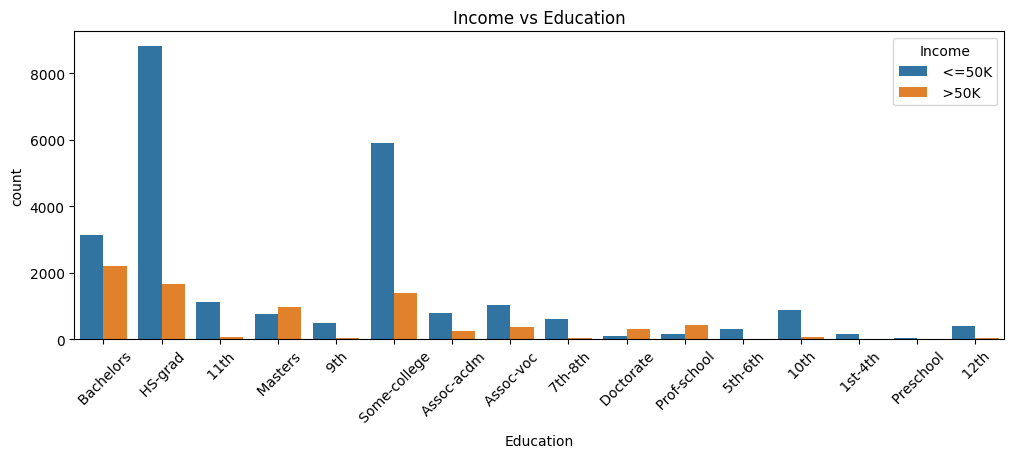

In [ ]:
# Income vs Sex
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Income', data=df)
plt.title('Income vs Sex')
plt.show()

# Income vs Education
plt.figure(figsize=(12,4))
sns.countplot(x='Education', hue='Income', data=df)
plt.title('Income vs Education')
plt.xticks(rotation=45) 
plt.show()

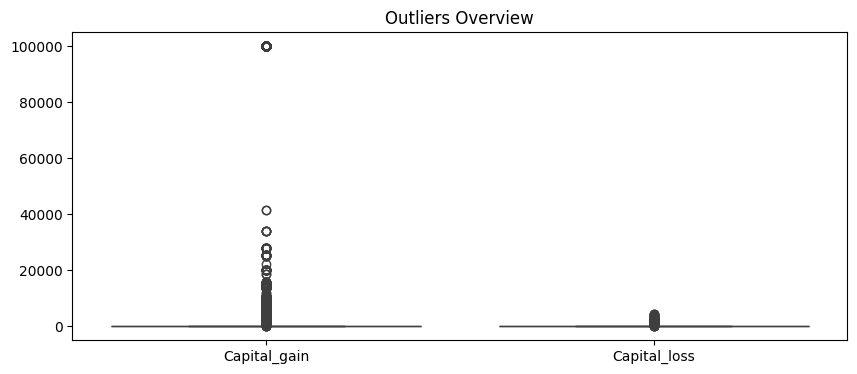

In [188]:
# Outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df[['Capital_gain', 'Capital_loss']])
plt.title('Outliers Overview')
plt.show()

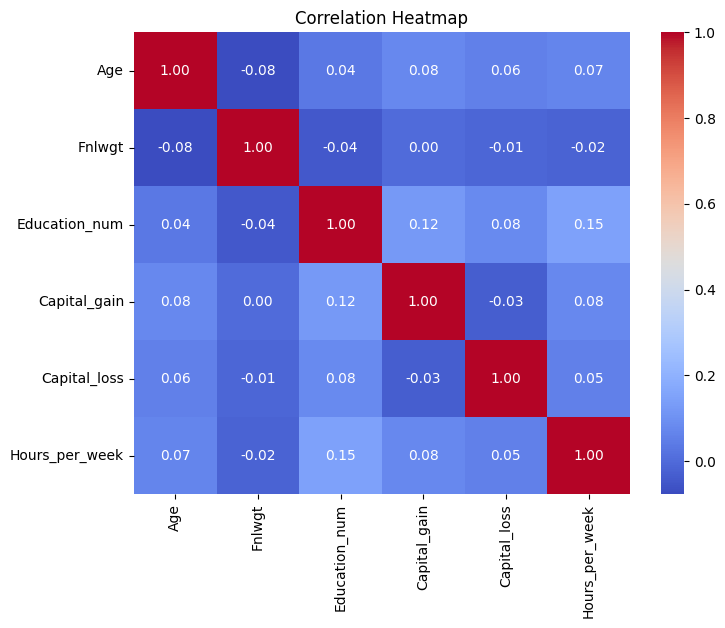

In [189]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Preprocessing

In [190]:
#Remove Duplicates
df=df.drop_duplicates()

#From Correlation, Fntwgt's in weak relation with other features
df=df.drop('Fnlwgt',axis=1)

#Remove ' ?' values
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

df.shape

(30138, 14)

In [191]:
# Encode target column: <=50K = 0, >50K = 1
df['Income'].unique()
df['Income']=df['Income'].map({' <=50K':0,' >50K':1})
df['Income'].value_counts()

Income
0    22632
1     7506
Name: count, dtype: int64

In [192]:
# one_hot encode for categorical data
categorical_col = ['Workclass', 'Education', 'Marital_status', 'Occupation', 'Relationship', 'Race', 'Native_country','Sex']
df = pd.get_dummies(df, columns=categorical_col, drop_first=True, dtype=int)

In [193]:
df['Capital_net'] = df['Capital_gain'] - df['Capital_loss']
df = df.drop(['Capital_gain', 'Capital_loss'], axis=1)
df.head()

,Age,Education_num,Hours_per_week,Income,Workclass_ Local-gov,Workclass_ Private,Workclass_ Self-emp-inc,Workclass_ Self-emp-not-inc,Workclass_ State-gov,Workclass_ Without-pay,...,Native_country_ Scotland,Native_country_ South,Native_country_ Taiwan,Native_country_ Thailand,Native_country_ Trinadad&Tobago,Native_country_ United-States,Native_country_ Vietnam,Native_country_ Yugoslavia,Sex_ Male,Capital_net
0,50,13,13,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
1,38,9,40,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,53,7,40,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,28,13,40,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,37,14,40,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


Data Spliting & Scaling

In [194]:
X=df.drop('Income', axis=1)
Y=df['Income']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Modeling

In [195]:
model=LogisticRegression( max_iter=1000 , random_state=42)
model.fit(X_train_scaled,y_train)
y_predict=model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_predict)
print(f"Accuracy: {acc * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_predict ))

print("\nClassification Report:")
print(classification_report(y_test, y_predict))

Accuracy: 84.74%

Confusion Matrix:
[[4184  343]
 [ 577  924]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4527
           1       0.73      0.62      0.67      1501

    accuracy                           0.85      6028
   macro avg       0.80      0.77      0.78      6028
weighted avg       0.84      0.85      0.84      6028



For Deploying

In [196]:
import joblib

#save
joblib.dump(model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

joblib.dump(list(X.columns), 'model_features.pkl')

print("All files saved successfully! 🚀")

All files saved successfully! 🚀
